# ⚡ Notebook 4 — Long Straddle
> Monthly ATM Straddle  |  30 DTE  |  Δ≈±0.50  |  Long Volatility

---

## 1. Theory

The long straddle is a **pure volatility** bet:

$$\text{P\&L} = |S_T - K| - (c + p)$$

**Break-evens**: $K \pm (c+p)$

Profitable when **realized vol > implied vol**. The exact opposite of the Buy-Write.

**Greeks:** Δ≈0, Γ>>0, Θ<<0, ν>>0 — maximum long vega.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from src.data_loader import load_data
from src.plotting    import *
from src.metrics     import compute_metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

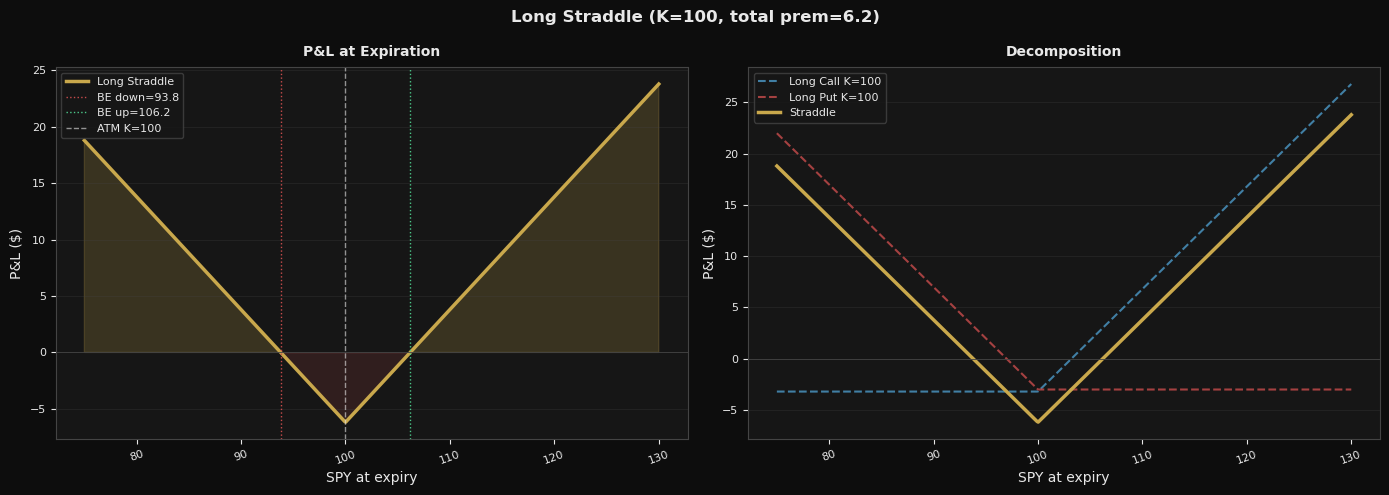

In [2]:
fig, axes = plt.subplots(1,2,figsize=(14,5),facecolor=BG)
K,c,p = 100,3.2,3.0; tot = c+p
ST = np.linspace(75,130,500)
pnl = np.abs(ST-K)-tot
axes[0].plot(ST,pnl,color=GOLD,lw=2.5,label='Long Straddle')
axes[0].fill_between(ST,pnl,0,where=pnl>0,alpha=0.2,color=GOLD)
axes[0].fill_between(ST,pnl,0,where=pnl<0,alpha=0.15,color=RED)
axes[0].axvline(K-tot,color=RED,  lw=1,ls=':',label=f'BE down={K-tot}')
axes[0].axvline(K+tot,color=GREEN,lw=1,ls=':',label=f'BE up={K+tot}')
axes[0].axvline(K,    color=WHITE, lw=1,ls='--',alpha=0.6,label=f'ATM K={K}')
style_ax(axes[0],'P&L at Expiration'); legend(axes[0])
axes[0].set_xlabel('SPY at expiry'); axes[0].set_ylabel('P&L ($)')
axes[1].plot(ST,np.maximum(ST-K,0)-c,color=BLUE,lw=1.5,ls='--',label=f'Long Call K={K}',alpha=0.8)
axes[1].plot(ST,np.maximum(K-ST,0)-p,color=RED, lw=1.5,ls='--',label=f'Long Put K={K}',alpha=0.8)
axes[1].plot(ST,pnl,color=GOLD,lw=2.5,label='Straddle')
style_ax(axes[1],'Decomposition'); legend(axes[1])
axes[1].set_xlabel('SPY at expiry'); axes[1].set_ylabel('P&L ($)')
fig.suptitle(f'Long Straddle (K={K}, total prem={tot})',color=WHITE,fontsize=12,fontweight='bold')
fig.patch.set_facecolor(BG); plt.tight_layout(); plt.show()

## 2. Strategy Construction

**No underlying position.**

$$V_t = \text{Cash}_t + \text{Call}_{\text{MTM},t} + \text{Put}_{\text{MTM},t}$$

At roll: `Cash -= (C_mid + P_mid)`  
At expiry: `Cash += payoff_call + payoff_put`

In [3]:


#DATA_PATH = '../data/spy_simulated_2020_2022.csv'
# Uncomment to use real data:
DATA_PATH = '../data/spy_2020_2022.csv'

df = load_data(DATA_PATH)
print('Data loaded:', df.shape)

✅  Loaded: ../data/spy_2020_2022.csv
    Rows            : 3,589,079
    Period          : 2020-01-02 → 2022-12-30
    Trading days    : 758
    Unique strikes  : 641
    Unique expiries : 514
Data loaded: (3589079, 35)


In [4]:
from src.strategy_straddle import build_straddle
std = build_straddle(df, target_dte=30)
std[['spy_price','index_level','spy_bnh','strike','total_premium','call_iv']].tail(10)

✅  Long Straddle index built
    Days            : 758
    Rolls           : 37
    Avg total prem  : 17.728
    Avg call IV     : 20.82%


,spy_price,index_level,spy_bnh,strike,total_premium,call_iv
date,,,,,,
2022-12-19,380.02,-138.900067,116.976021,403.0,17.105,0.18852
2022-12-20,380.49,-143.259557,117.120694,403.0,17.105,0.18852
2022-12-21,386.21,-216.029510,118.881399,403.0,17.105,0.18852
2022-12-22,380.72,-143.661972,117.191492,403.0,17.105,0.18852
2022-12-23,382.88,-174.647887,117.856373,384.0,16.895,0.19732
2022-12-26,382.91,-174.983233,117.865608,384.0,16.895,0.19732
2022-12-27,381.38,-181.824279,117.394650,384.0,16.895,0.19732
2022-12-28,376.71,-176.324614,115.957152,384.0,16.895,0.19732
2022-12-29,383.33,-191.012743,117.994890,384.0,16.895,0.19732


## 3. Performance Dashboard

/Users/kingced/Desktop/PersonalTraining/Options strat/Option Index Strat /spy_options_repo/src/metrics.py:35: RuntimeWarning: invalid value encountered in scalar power
  ann_ret    = (1 + r).prod() ** (periods / n) - 1


  Chart saved → ../outputs/chart_straddle.png


/Users/kingced/Desktop/PersonalTraining/Options strat/Option Index Strat /spy_options_repo/src/plotting.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


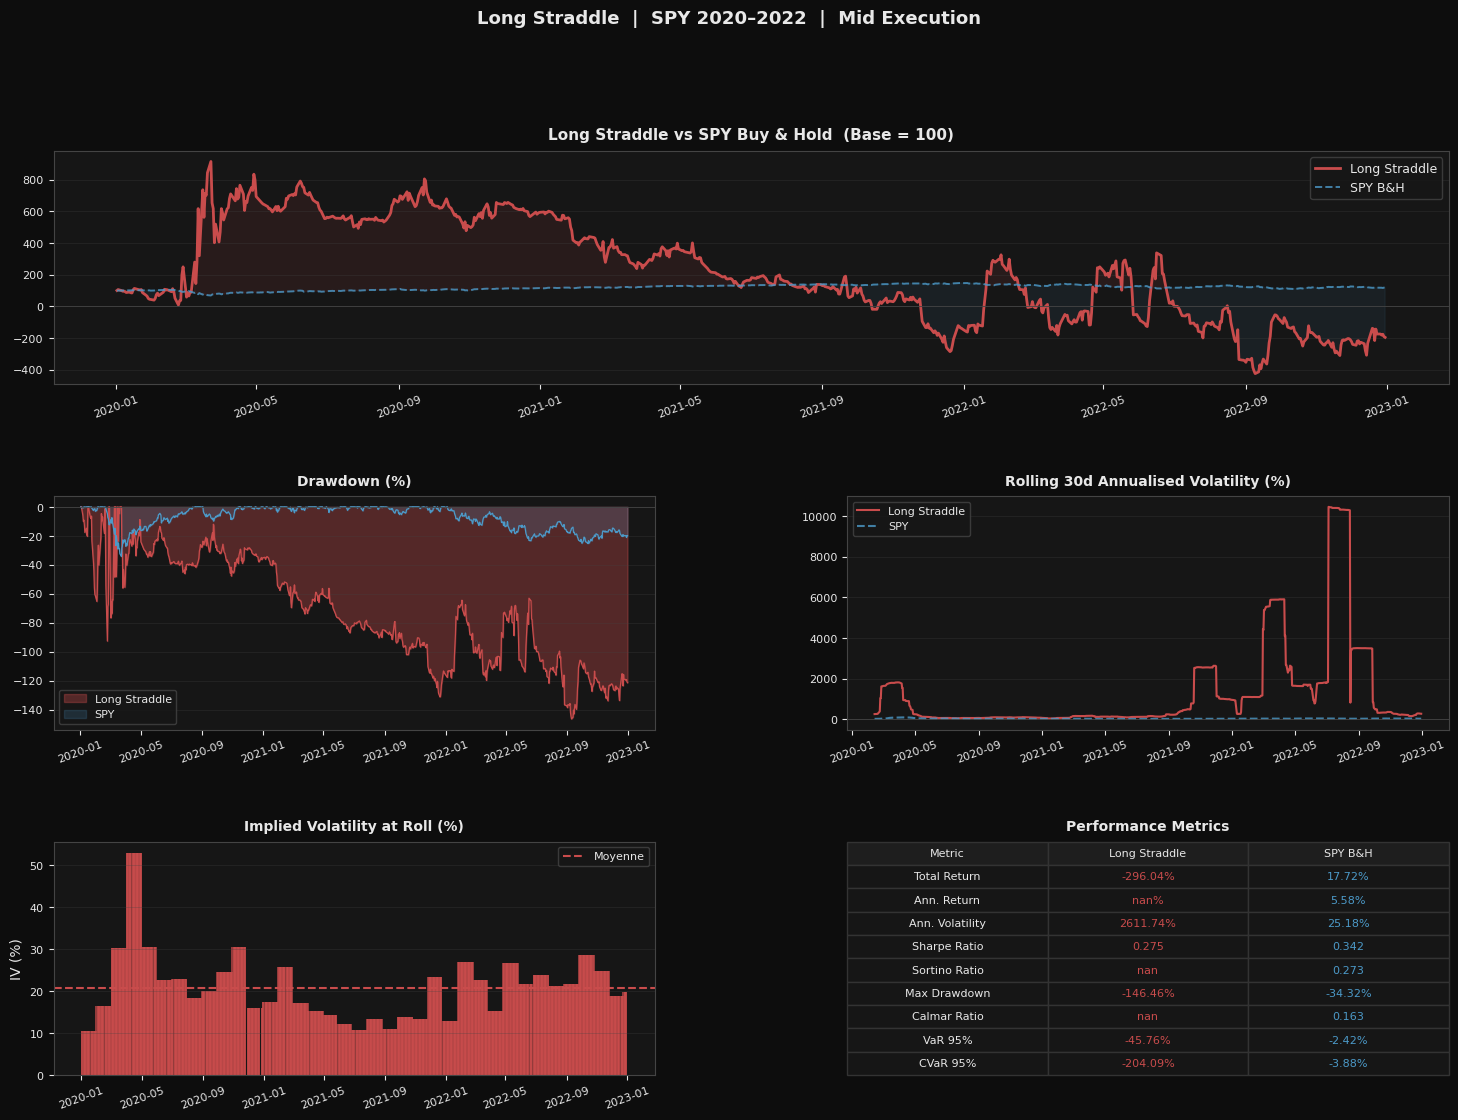

In [5]:
from src.plotting import plot_strategy_dashboard
plot_strategy_dashboard(std, 'Long Straddle', RED,
                        save_path='../outputs/chart_straddle.png')

## 4. Metrics

In [6]:
m = compute_metrics(std)
for k,v in m.items():
    if isinstance(v,float): print(f'  {k:<25} {v:.4f}')

  Total Return              -2.9604
  Ann. Return               nan
  Ann. Volatility           26.1174
  Skewness                  12.2182
  Kurtosis                  301.0740
  Max Drawdown              -1.4646
  Avg DD Duration           106.7143
  Sharpe Ratio              0.2753
  Sortino Ratio             nan
  Calmar Ratio              nan
  Omega Ratio               1.1958
  VaR 95%                   -0.4576
  CVaR 95%                  -2.0409


/Users/kingced/Desktop/PersonalTraining/Options strat/Option Index Strat /spy_options_repo/src/metrics.py:35: RuntimeWarning: invalid value encountered in scalar power
  ann_ret    = (1 + r).prod() ** (periods / n) - 1
